In [1]:
# ── Colab Setup (skip automatically if running locally) ──────────────────────
import sys, os

# Reproducibility pin: check out this exact commit inside the Colab clone so
# scripts/models/*.py and data/splits/*.parquet match the code+data these
# notebook cells were run against — `git clone --branch Model` alone would
# silently pull the branch's latest tip instead. Bump this hash per logged run.
TARGET_COMMIT = '59a1415'

IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    import subprocess
    # transformers provides HuggingFace PatchTST (fully multivariate)
    subprocess.run(['pip', 'install', 'transformers', '-q'], check=True)

    # Clone the repo (git-tracked data/splits/*.parquet come along for free —
    #    no manual upload needed), pinned to TARGET_COMMIT
    REPO_URL = 'https://github.com/WoodyChang21/ECE1508_GenAI.git'
    if not os.path.exists('/content/ECE1508_GenAI'):
        subprocess.run(
            ['git', 'clone', '--branch', 'Model', REPO_URL, '/content/ECE1508_GenAI'],
            check=True,
        )
    subprocess.run(['git', '-C', '/content/ECE1508_GenAI', 'fetch', 'origin'], check=True)
    subprocess.run(['git', '-C', '/content/ECE1508_GenAI', 'checkout', TARGET_COMMIT], check=True)
    print(f"Checked out /content/ECE1508_GenAI at {TARGET_COMMIT}")
    os.chdir('/content/ECE1508_GenAI/notebooks')

    os.makedirs('/content/ECE1508_GenAI/data/predictions', exist_ok=True)

    missing = [
        f for f in ['train.parquet', 'val.parquet', 'test.parquet']
        if not os.path.exists(f'/content/ECE1508_GenAI/data/splits/{f}')
    ]
    if missing:
        raise FileNotFoundError(
            'Missing data splits after clone: ' + ', '.join(missing)
            + f'. Ensure commit {TARGET_COMMIT} includes data/splits/*.parquet.'
        )
    print('Data splits found from clone — no upload needed.')

    import torch
    if torch.cuda.is_available():
        print(f'\nGPU: {torch.cuda.get_device_name(0)}')
    else:
        print('\nNo GPU detected. Go to Runtime -> Change runtime type -> T4 GPU.')

print('Setup complete.')


Checked out /content/ECE1508_GenAI at 59a1415
Data splits found from clone — no upload needed.

GPU: NVIDIA A100-SXM4-80GB
Setup complete.


In [2]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import itertools
import gc
import torch
import matplotlib.pyplot as plt
from neuralforecast import NeuralForecast
from neuralforecast.models import DeepAR
from neuralforecast.losses.pytorch import DistributionLoss, MQLoss

from scripts.models.data_loader import load_nf_dataframe, build_full_df, FUTR_EXOG_COLS
from scripts.models.metrics import compute_all

plt.rcParams['figure.figsize'] = (14, 4)

# Model-wise tuning grid. `input_size` alone was flat across two data-config
# runs (see docs/experiments.md) — widen the search instead of spending more
# compute on that single axis. Data config (FUTR_EXOG_COLS) is controlled
# separately in scripts/models/data_loader.py and is untouched here.
INPUT_SIZE_CANDIDATES  = [24, 60, 120, 240]
HIDDEN_SIZE_CANDIDATES = [64, 128]
SCALER_CANDIDATES      = ['standard', 'robust']
FREQ = 1   # integer ds — avoids market-hours gap issues

In [3]:
extra = FUTR_EXOG_COLS  # data-wise config lives in scripts/models/data_loader.py

train_df = load_nf_dataframe('../data/splits/train.parquet', extra_cols=extra)
val_df   = load_nf_dataframe('../data/splits/val.parquet',   extra_cols=extra)
test_df  = load_nf_dataframe('../data/splits/test.parquet',  extra_cols=extra)

# Contiguous ds sequences for cross_validation
trainval_df = build_full_df([train_df, val_df])
full_df     = build_full_df([train_df, val_df, test_df])

print(f"train: {len(train_df):,}  val: {len(val_df):,}  test: {len(test_df):,}")
print(f"trainval: {len(trainval_df):,}  full: {len(full_df):,}")
print(f"futr_exog columns ({len(FUTR_EXOG_COLS)}): {FUTR_EXOG_COLS}")
print(full_df.head(3))

train: 21,028  val: 1,744  test: 2,469
trainval: 22,772  full: 25,241
futr_exog columns (13): ['is_first_bar', 'is_last_bar', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'is_monday', 'is_friday', 'month_sin', 'month_cos', 'is_month_end', 'is_month_start', 'is_quarter_end']
  unique_id  ds         y  is_first_bar  is_last_bar  hour_sin  hour_cos  \
0       SPY   0 -0.002645         False        False  0.935016 -0.354605   
1       SPY   1  0.001623         False        False  0.239316 -0.970942   
2       SPY   2  0.000473         False         True -0.464723  0.885456   

    dow_sin   dow_cos  is_monday  is_friday  month_sin  month_cos  \
0  0.951057  0.309017      False      False        0.0        1.0   
1  0.951057  0.309017      False      False        0.0        1.0   
2  0.951057  0.309017      False      False        0.0        1.0   

   is_month_end  is_month_start  is_quarter_end  
0         False           False           False  
1         False           False           

In [4]:
# ── Model-wise tuning: grid over input_size x lstm_hidden_size x scaler_type ──
# input_size alone was flat in prior data-wise runs, so the tuning budget is
# spent on two more axes instead: LSTM capacity and normalization robustness
# (return_1h has kurtosis ~39 — 'robust' scaling may handle that better than
# mean/std 'standard' scaling).
val_maes     = {}
val_cv_cache = {}   # config -> validation cross_validation DataFrame (used for conformal calibration below)

grid = list(itertools.product(INPUT_SIZE_CANDIDATES, HIDDEN_SIZE_CANDIDATES, SCALER_CANDIDATES))
print(f"Tuning {len(grid)} configs (input_size x lstm_hidden_size x scaler_type)...")

for input_size, hidden_size, scaler_type in grid:
    model = DeepAR(
        h=1,
        input_size=input_size,
        lstm_hidden_size=hidden_size,
        lstm_n_layers=2,
        lstm_dropout=0.1,
        trajectory_samples=100,          # fewer samples for speed during tuning
        loss=DistributionLoss(distribution='StudentT', level=[80, 90]),
        valid_loss=MQLoss(level=[80, 90]),
        futr_exog_list=FUTR_EXOG_COLS,
        max_steps=500,
        early_stop_patience_steps=-1,    # disable early stopping; cross_validation has no val split
        scaler_type=scaler_type,
    )
    nf = NeuralForecast(models=[model], freq=FREQ)
    # cross_validation treats last test_size rows of trainval_df as the "test" (= val here)
    # n_windows=None is required when test_size is provided (NeuralForecast 1.7.7 API)
    cv = nf.cross_validation(
        df=trainval_df,
        n_windows=None,
        test_size=len(val_df),
        step_size=1,
        refit=False,
    )
    val_mae = float(np.mean(np.abs(cv['y'].values - cv['DeepAR'].values)))
    config = (input_size, hidden_size, scaler_type)
    val_maes[config]     = val_mae
    val_cv_cache[config] = cv
    print(f"  input_size={input_size:3d}  hidden={hidden_size:3d}  scaler={scaler_type:8s}  val MAE={val_mae:.6f}")

    del model, nf
    gc.collect()
    torch.cuda.empty_cache()

best_config = min(val_maes, key=val_maes.get)
best_input_size, best_hidden_size, best_scaler_type = best_config
print(f"\nBest config: input_size={best_input_size}  lstm_hidden_size={best_hidden_size}  "
      f"scaler_type={best_scaler_type}  (val MAE={val_maes[best_config]:.6f})")

# Conformal calibration source: residuals from the winning config's own validation
# predictions (model never saw these rows as training targets — no leakage).
# error = true - pred, matching the convention already used in patchtst.ipynb.
best_cv    = val_cv_cache[best_config]
val_errors = best_cv['y'].values - best_cv['DeepAR'].values

INFO:lightning_fabric.utilities.seed:Seed set to 1


Tuning 16 configs (input_size x lstm_hidden_size x scaler_type)...


INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:You are using a CUDA device ('NVIDIA A100-SXM4-80GB') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.callbacks.model_summary:
  | Name                | Type             | Params | Mode 
-----------------------------------------------------------------
0 | loss                | DistributionLoss | 5      | train
1 | valid_loss          | MQLoss           | 5      | train
2 | hist_cat_embeddings | ModuleList       | 0      

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_steps=500` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: |          | 0/? [00:00<?, ?it/s]

  input_size=240  hidden=128  scaler=robust    val MAE=0.002154

Best config: input_size=240  lstm_hidden_size=64  scaler_type=robust  (val MAE=0.002142)


In [5]:
# Train on train+val (full_df minus last test_size rows), predict across test
final_model = DeepAR(
    h=1,
    input_size=best_input_size,
    lstm_hidden_size=best_hidden_size,
    lstm_n_layers=2,
    lstm_dropout=0.1,
    trajectory_samples=500,   # up from 200 — at h=1 these are MC draws from an
                               # already-decoded distribution (no extra LSTM passes),
                               # so more samples just reduce sampling noise for free
    loss=DistributionLoss(distribution='StudentT', level=[80, 90]),
    valid_loss=MQLoss(level=[80, 90]),
    futr_exog_list=FUTR_EXOG_COLS,
    max_steps=1000,
    early_stop_patience_steps=-1,    # disable early stopping; cross_validation has no val split
    scaler_type=best_scaler_type,
)
nf_final = NeuralForecast(models=[final_model], freq=FREQ)

# n_windows=None is required when test_size is provided (NeuralForecast 1.7.7 API)
cv_test = nf_final.cross_validation(
    df=full_df,
    n_windows=None,
    test_size=len(test_df),
    step_size=1,
    refit=False,
)

print(f"Test predictions: {len(cv_test):,} rows")
print(f"Columns: {list(cv_test.columns)}")

INFO:lightning_fabric.utilities.seed:Seed set to 1
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.callbacks.model_summary:
  | Name                | Type             | Params | Mode 
-----------------------------------------------------------------
0 | loss                | DistributionLoss | 5      | train
1 | valid_loss          | MQLoss           | 5      | train
2 | hist_cat_embeddings | ModuleList       | 0      | train
3 | futr_cat_embeddings | ModuleList       | 0      | train
4 | stat_cat_embeddings | ModuleList       | 0      | train
5 | padder_train        | ConstantPad1d    | 0      | train
6 | scaler              | TemporalNorm     | 0      | train
7 | hist_encoder        | LSTM             | 53.8 K | train
8 | decoder             | MLP              | 1

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_steps=1000` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: |          | 0/? [00:00<?, ?it/s]

Test predictions: 2,469 rows
Columns: ['unique_id', 'ds', 'cutoff', 'DeepAR', 'DeepAR-median', 'DeepAR-lo-90', 'DeepAR-lo-80', 'DeepAR-hi-80', 'DeepAR-hi-90', 'y']


In [6]:
y_true = cv_test['y'].values
y_pred = cv_test['DeepAR'].values

# Parametric intervals (DeepAR's fitted StudentT distribution) — kept for comparison only
lo_80_param = cv_test['DeepAR-lo-80'].values
hi_80_param = cv_test['DeepAR-hi-80'].values
lo_90_param = cv_test['DeepAR-lo-90'].values
hi_90_param = cv_test['DeepAR-hi-90'].values

# Conformal intervals — calibrated from the winning config's validation residuals
# (val_errors from the tuning cell). Same convention as patchtst.ipynb:
# error = true - pred, so lower bound = pred + q_low(error), upper bound = pred + q_high(error).
q = {lvl: float(np.quantile(val_errors, lvl)) for lvl in [0.05, 0.10, 0.90, 0.95]}
lo_80 = y_pred + q[0.10]
hi_80 = y_pred + q[0.90]
lo_90 = y_pred + q[0.05]
hi_90 = y_pred + q[0.95]

results          = compute_all(y_true, y_pred, lo_80, hi_80, lo_90, hi_90)
results_param    = compute_all(y_true, y_pred, lo_80_param, hi_80_param, lo_90_param, hi_90_param)

print("=== DeepAR Test Results (conformal intervals) ===")
print(f"  RMSE              : {results['rmse']:.6f}")
print(f"  MAE               : {results['mae']:.6f}")
print(f"  Directional Acc   : {results['dir_acc']:.4f}")
print(f"  Coverage 80%      : {results['coverage_80']:.4f}  (target: 0.80)")
print(f"  Coverage 90%      : {results['coverage_90']:.4f}  (target: 0.90)")
print(f"  Sharpe Ratio      : {results['sharpe']:.4f}")
print(f"  Max Drawdown      : {results['max_drawdown']:.6f}")

print("\n=== For comparison: parametric StudentT intervals (same point forecast) ===")
print(f"  Coverage 80%      : {results_param['coverage_80']:.4f}  (target: 0.80)")
print(f"  Coverage 90%      : {results_param['coverage_90']:.4f}  (target: 0.90)")

=== DeepAR Test Results (conformal intervals) ===
  RMSE              : 0.004151
  MAE               : 0.002351
  Directional Acc   : 0.5209
  Coverage 80%      : 0.7967  (target: 0.80)
  Coverage 90%      : 0.8870  (target: 0.90)
  Sharpe Ratio      : 0.1549
  Max Drawdown      : -0.292637

=== For comparison: parametric StudentT intervals (same point forecast) ===
  Coverage 80%      : 0.7963  (target: 0.80)
  Coverage 90%      : 0.8886  (target: 0.90)


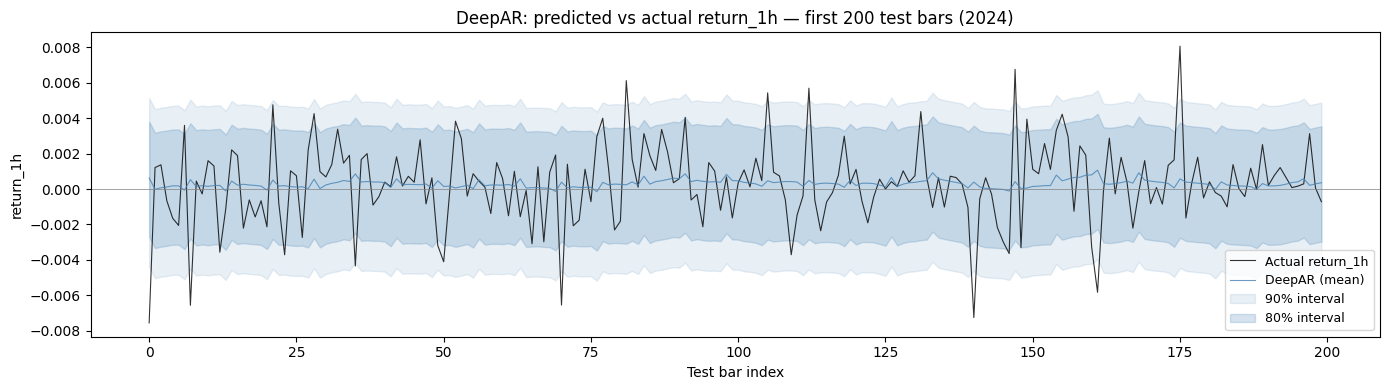

In [7]:
n = 200
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(range(n), y_true[:n], label='Actual return_1h', alpha=0.8, linewidth=0.8, color='black')
ax.plot(range(n), y_pred[:n], label='DeepAR (mean)',    alpha=0.8, linewidth=0.8, color='steelblue')
ax.fill_between(range(n), lo_90[:n], hi_90[:n], alpha=0.12, color='steelblue', label='90% interval')
ax.fill_between(range(n), lo_80[:n], hi_80[:n], alpha=0.22, color='steelblue', label='80% interval')
ax.axhline(0, color='gray', linewidth=0.5)
ax.legend(fontsize=9)
ax.set_title('DeepAR: predicted vs actual return_1h — first 200 test bars (2024)')
ax.set_xlabel('Test bar index')
ax.set_ylabel('return_1h')
plt.tight_layout()
plt.show()

In [8]:
test_raw = pd.read_parquet('../data/splits/test.parquet').reset_index(drop=True)

preds_df = pd.DataFrame({
    'ds':       cv_test['ds'].values,
    'datetime': test_raw['datetime'].values[:len(cv_test)],
    'y':        y_true,
    'pred':     y_pred,
    'lo_80':    lo_80,
    'hi_80':    hi_80,
    'lo_90':    lo_90,
    'hi_90':    hi_90,
    'model':    'DeepAR',
})
preds_df.to_parquet('../data/predictions/deepar_preds.parquet', index=False)
print(f"Saved {len(preds_df):,} rows → data/predictions/deepar_preds.parquet")
print(preds_df.head(3))

Saved 2,469 rows → data/predictions/deepar_preds.parquet
      ds            datetime         y      pred     lo_80     hi_80  \
0  22772 2024-01-02 09:30:00 -0.007552  0.000622 -0.002698  0.003804   
1  22773 2024-01-02 10:30:00  0.001208 -0.000016 -0.003336  0.003166   
2  22774 2024-01-02 11:30:00  0.001366  0.000070 -0.003250  0.003251   

      lo_90     hi_90   model  
0 -0.004396  0.005138  DeepAR  
1 -0.005034  0.004499  DeepAR  
2 -0.004948  0.004585  DeepAR  
